In [16]:
!pip install geopandas
!pip install geodatasets

In [17]:
import pandas as pd
import geopandas as gpd

# Lê o CSV com cabeçalho
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/Unidades_Basicas_Saude-UBS.csv",
    sep=";",
    encoding="latin-1"
)

# Veja os nomes reais das colunas
print(df.columns.tolist())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['CNES', 'UF', 'IBGE', 'NOME', 'LOGRADOURO', 'BAIRRO', 'LATITUDE', 'LONGITUDE']


,CNES,UF,IBGE,NOME,LOGRADOURO,BAIRRO,LATITUDE,LONGITUDE
0,23914,31,310620,CENTRO DE SAUDE JARDIM MONTANHES,RUA SAUDE,PADRE EUSTAQUIO,-19.911503,"-43,9914089036"
1,106143,26,261000,UBS FRANCISCO VIEIRA DE MELO,QUADRA 50,QUILOMBO II,-8.705590,"-35,5995386839"
2,302,26,260290,USF SANTO ESTEVAO,RUA DO CEMITERIO,PONTE DOS CARVALHOS,-8.218112,"-35,2294359"
3,405132,26,261350,UNIDADE DE SAUDE SABINO LUCAS DE BARROS,TRAVESSA SAO PAULO,VILA DELMIRO,-7.866081,"-38,7650871277"
4,881007,26,261000,UBS MARIA ALICE,QUADRA 11,QUILOMBO 2,-8.698513,"-35,6040179729"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_20488/2894861550.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(data_box, labels=labels_box, patch_artist=True, notch=False,medianprops={"color":"black","linewidth":2})


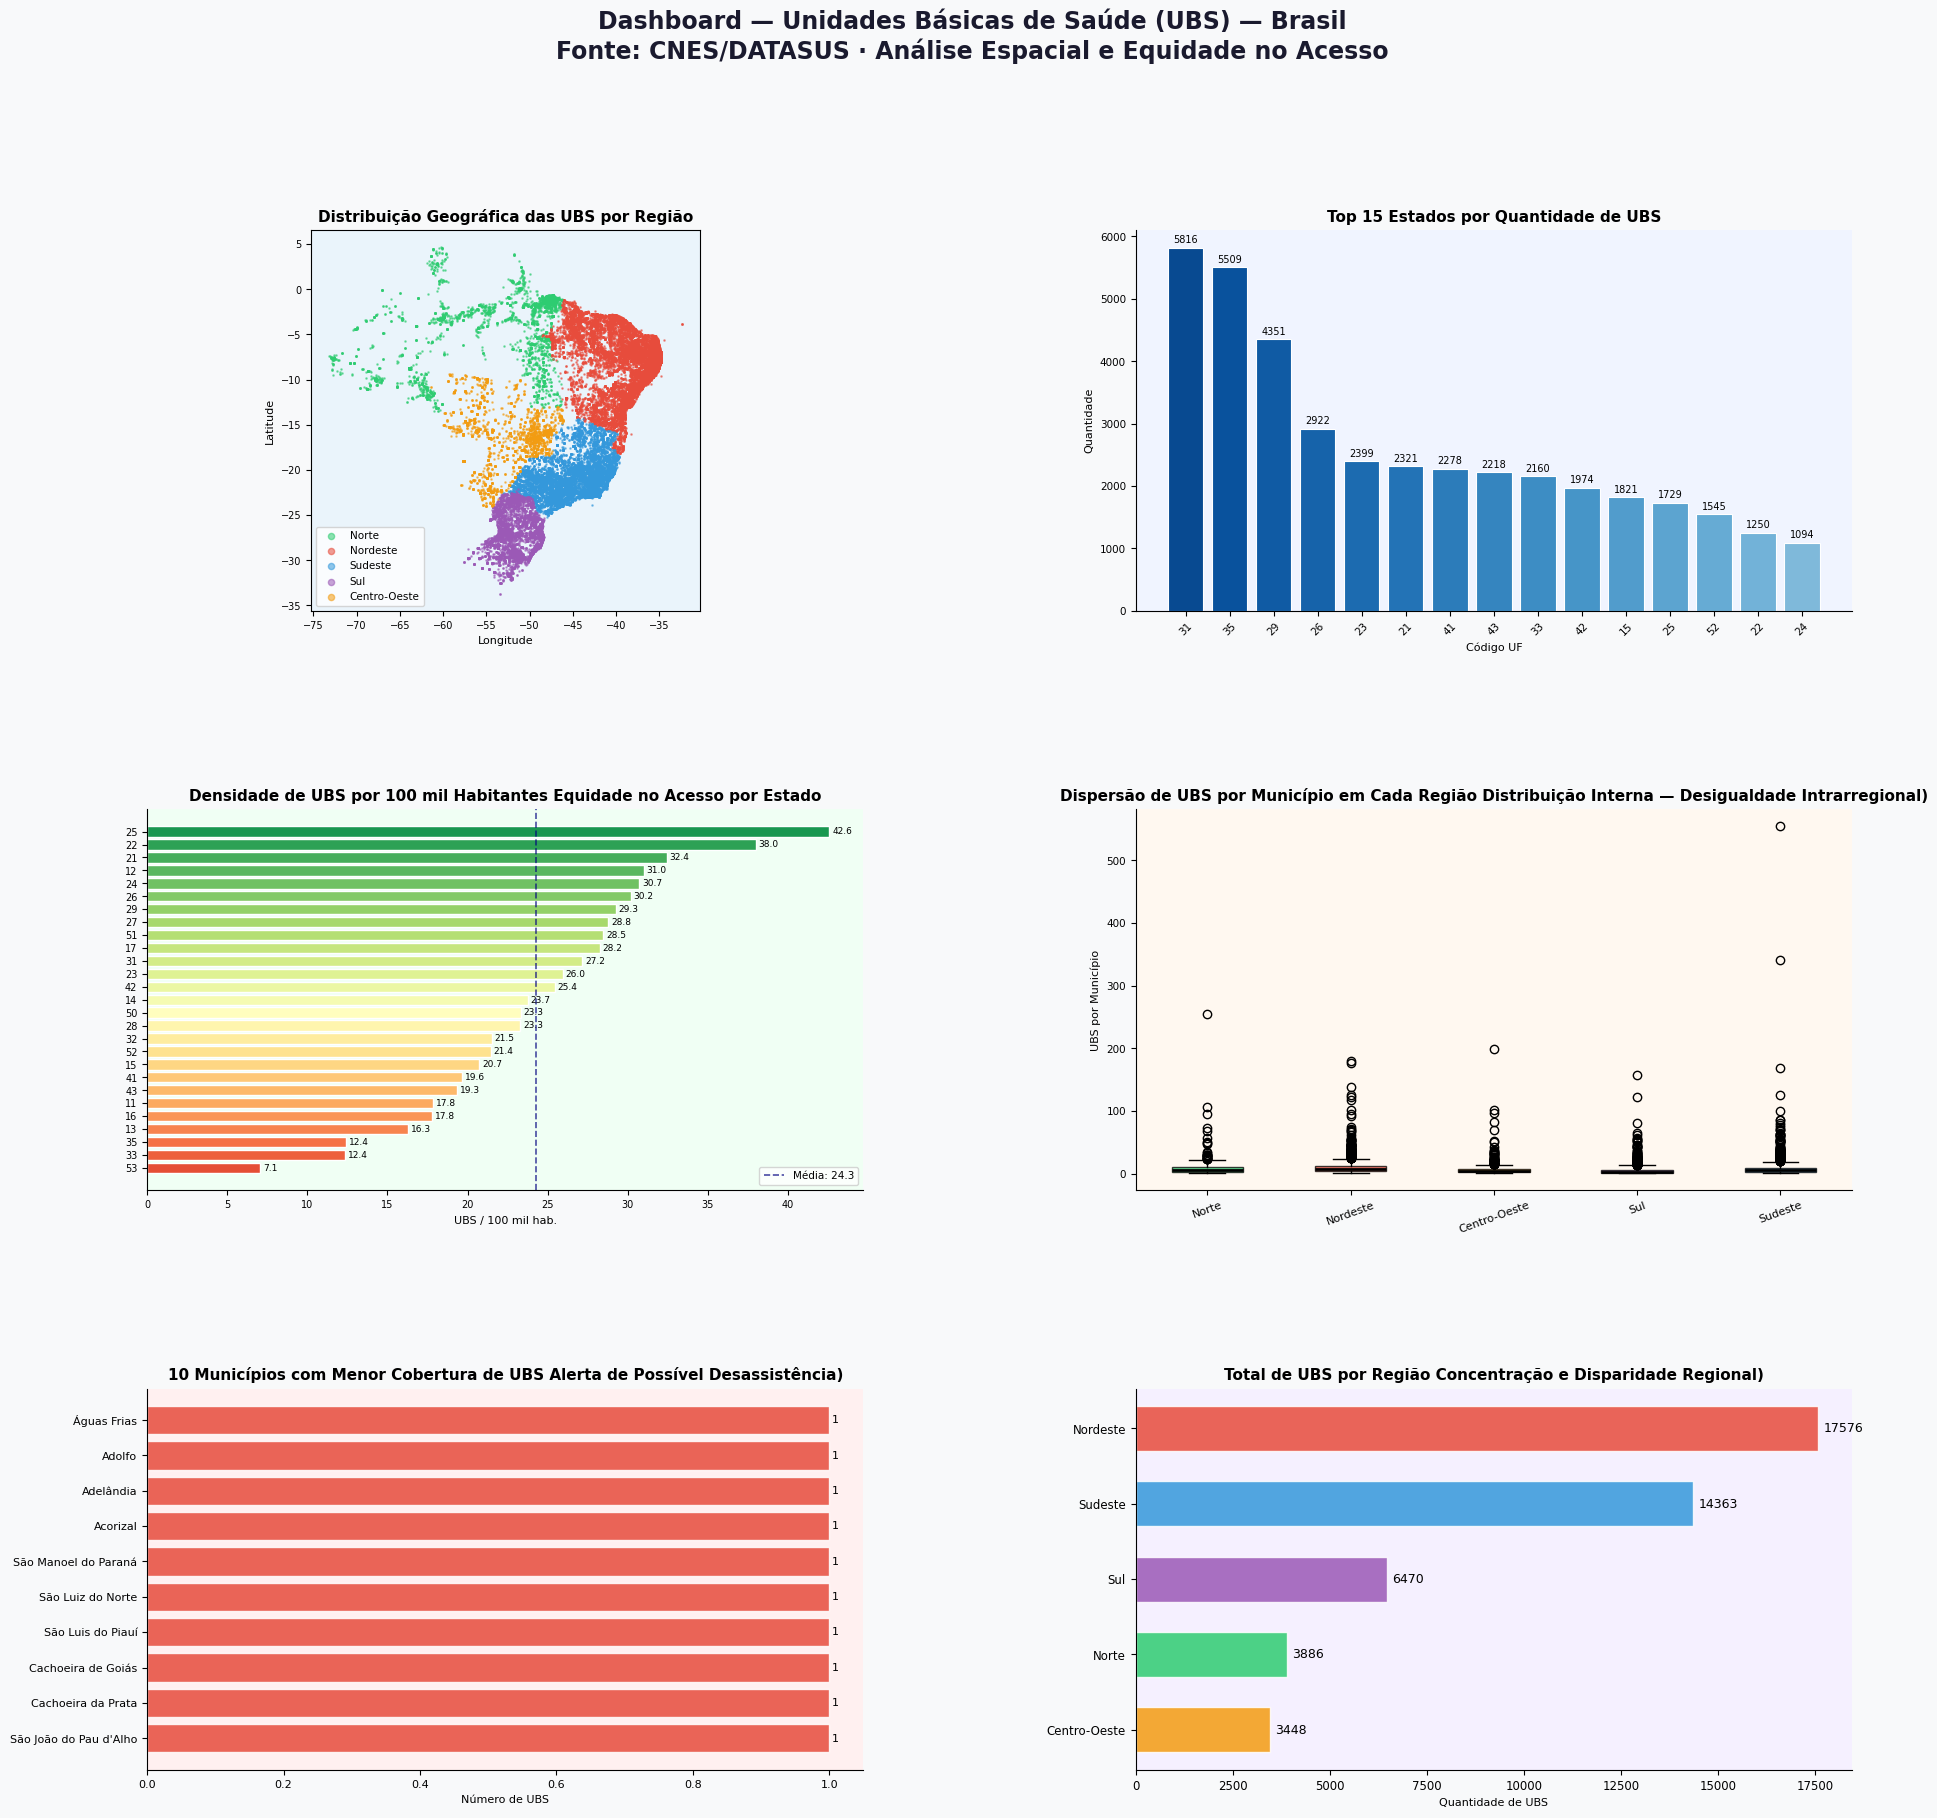

  SUMÁRIO ANALÍTICO — UBS NO BRASIL
Total de UBS cadastradas no CNES : 45,743
Estados cobertos                 : 27
Municípios cobertos              : 5216
Estado com mais UBS (absoluto)   : UF 31
Município com mais UBS           : São Paulo
Região com menos UBS             : Centro-Oeste
Maior densidade (UBS/100k hab.)  : UF 25 → 42.59
Menor densidade (UBS/100k hab.)  : UF 53 → 7.06
Razão max/min densidade          : 6.0x


In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ─── 1. LÊ O CSV ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/Unidades_Basicas_Saude-UBS.csv",
    sep=";",
    encoding="latin-1"
)

df["LONGITUDE"] = df["LONGITUDE"].astype(str).str.replace(",", ".").astype(float)
df["LATITUDE"]  = df["LATITUDE"].astype(float)
df = df.dropna(subset=["LATITUDE", "LONGITUDE"])

# ─── 2. BUSCA NOMES DOS MUNICÍPIOS (IBGE) ────────────────
url_ibge = "https://raw.githubusercontent.com/kelvins/municipios-brasileiros/main/csv/municipios.csv"
municipios = pd.read_csv(url_ibge)
municipios = municipios[["codigo_ibge", "nome", "capital"]].copy()
municipios["codigo_ibge"] = municipios["codigo_ibge"].astype(str).str[:6]
df["IBGE"] = df["IBGE"].astype(str).str[:6]

df = df.merge(municipios, left_on="IBGE", right_on="codigo_ibge", how="left")

# ─── 3. MAPA DE REGIÕES ──────────────────────────────────
regioes = {
    "11":"Norte","12":"Norte","13":"Norte","14":"Norte","15":"Norte","16":"Norte","17":"Norte",
    "21":"Nordeste","22":"Nordeste","23":"Nordeste","24":"Nordeste","25":"Nordeste",
    "26":"Nordeste","27":"Nordeste","28":"Nordeste","29":"Nordeste",
    "31":"Sudeste","32":"Sudeste","33":"Sudeste","35":"Sudeste",
    "41":"Sul","42":"Sul","43":"Sul",
    "50":"Centro-Oeste","51":"Centro-Oeste","52":"Centro-Oeste","53":"Centro-Oeste"
}
df["REGIAO"] = df["UF"].astype(str).str.zfill(2).map(regioes)

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["LONGITUDE"], df["LATITUDE"]), crs="EPSG:4326")

# ─── 4. DADOS POPULACIONAIS POR UF (IBGE Censo 2022) ─────
pop_uf = {
    11: 1815278,  12: 906876,  13: 4269995, 14: 652713,  15: 8777124,
    16: 877613,   17: 1607363, 21: 7153262, 22: 3289290, 23: 9240580,
    24: 3560903,  25: 4059905, 26: 9674793, 27: 3351543, 28: 2338474,
    29: 14873064, 31: 21411923,32: 4082727, 33: 17463349,35: 44420459,
    41: 11597484, 42: 7762154, 43: 11466630,50: 2839738, 51: 3658489,
    52: 7206589,  53: 2817068
}
df["POP"] = df["UF"].map(pop_uf)

# ─── 5. ESFERA ADMINISTRATIVA ────────────────────────────
esfera_map = {1: "Municipal", 2: "Estadual", 3: "Federal", 4: "Privada"}
if "ESFERA_ADMINISTRATIVA" in df.columns:
    df["ESFERA"] = df["ESFERA_ADMINISTRATIVA"].map(esfera_map).fillna("Não informada")
elif "TP_ESFERA" in df.columns:
    df["ESFERA"] = df["TP_ESFERA"].map(esfera_map).fillna("Não informada")
else:
    df["ESFERA"] = "Municipal"  # UBS são majoritariamente municipais

# ─── 6. DASHBOARD 6 GRÁFICOS ─────────────────────────────
cores = {"Norte":"#2ecc71","Nordeste":"#e74c3c","Sudeste":"#3498db","Sul":"#9b59b6","Centro-Oeste":"#f39c12"}

fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor("#f8f9fa")
fig.suptitle("Dashboard — Unidades Básicas de Saúde (UBS) — Brasil\nFonte: CNES/DATASUS · Análise Espacial e Equidade no Acesso",fontsize=17, fontweight="bold", y=0.99, color="#1a1a2e")
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.38)

# ── GRÁFICO 1 — Mapa Geográfico ──────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#eaf4fb")
for regiao, cor in cores.items():
    sub = gdf[gdf["REGIAO"] == regiao]
    sub.plot(ax=ax1, color=cor, markersize=0.8, alpha=0.55, label=regiao)
ax1.set_title("Distribuição Geográfica das UBS por Região", fontweight="bold", fontsize=11)
ax1.legend(loc="lower left", fontsize=7.5, markerscale=5, framealpha=0.8)
ax1.set_xlabel("Longitude", fontsize=8); ax1.set_ylabel("Latitude", fontsize=8)
ax1.tick_params(labelsize=7)

# ── GRÁFICO 2 — UBS por Estado (top 15) ──────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#f0f4ff")
ubs_uf = df["UF"].value_counts().head(15)
cores_bar = plt.cm.Blues(np.linspace(0.45, 0.9, len(ubs_uf)))[::-1]
bars = ax2.bar(ubs_uf.index.astype(str), ubs_uf.values, color=cores_bar, edgecolor="white", linewidth=0.8)
ax2.bar_label(bars, fontsize=7, padding=2, fmt="%d")
ax2.set_title("Top 15 Estados por Quantidade de UBS", fontweight="bold", fontsize=11)
ax2.set_xlabel("Código UF", fontsize=8); ax2.set_ylabel("Quantidade", fontsize=8)
ax2.tick_params(axis="x", rotation=45, labelsize=7.5)
ax2.tick_params(axis="y", labelsize=7.5)
ax2.spines[["top","right"]].set_visible(False)

# ── GRÁFICO 3 — NOVO: Densidade de UBS por 100 mil hab. ──
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor("#f0fff4")
ubs_por_uf = df.groupby("UF")["CNES"].count().reset_index()
ubs_por_uf.columns = ["UF", "N_UBS"]
ubs_por_uf["POP"] = ubs_por_uf["UF"].map(pop_uf)
ubs_por_uf["DENSIDADE"] = (ubs_por_uf["N_UBS"] / ubs_por_uf["POP"]) * 100000
ubs_por_uf = ubs_por_uf.dropna(subset=["DENSIDADE"]).sort_values("DENSIDADE", ascending=True)
cores_dens = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(ubs_por_uf)))
bars3 = ax3.barh(ubs_por_uf["UF"].astype(str), ubs_por_uf["DENSIDADE"], color=cores_dens, edgecolor="white")
ax3.bar_label(bars3, fmt="%.1f", fontsize=6.5, padding=2)
ax3.set_title("Densidade de UBS por 100 mil Habitantes Equidade no Acesso por Estado",fontweight="bold", fontsize=11)
ax3.set_xlabel("UBS / 100 mil hab.", fontsize=8)
ax3.tick_params(labelsize=7)
ax3.spines[["top","right"]].set_visible(False)
ax3.axvline(ubs_por_uf["DENSIDADE"].mean(), color="navy", linestyle="--", linewidth=1.2, alpha=0.7, label=f"Média: {ubs_por_uf['DENSIDADE'].mean():.1f}")
ax3.legend(fontsize=7.5)

# ── GRÁFICO 4 — NOVO: UBS por Região (boxplot de densidade municipal) ──
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor("#fff8f0")
ubs_mun_reg = df.groupby(["nome", "REGIAO"])["CNES"].count().reset_index()
ubs_mun_reg.columns = ["Municipio", "Regiao", "N_UBS"]
regioes_ord = ["Norte", "Nordeste", "Centro-Oeste", "Sul", "Sudeste"]
data_box = [ubs_mun_reg[ubs_mun_reg["Regiao"]==r]["N_UBS"].values for r in regioes_ord if r in ubs_mun_reg["Regiao"].values]
labels_box = [r for r in regioes_ord if r in ubs_mun_reg["Regiao"].values]
bp = ax4.boxplot(data_box, labels=labels_box, patch_artist=True, notch=False,medianprops={"color":"black","linewidth":2})
for patch, reg in zip(bp["boxes"], labels_box):
    patch.set_facecolor(cores.get(reg, "gray"))
    patch.set_alpha(0.75)
ax4.set_title("Dispersão de UBS por Município em Cada Região Distribuição Interna — Desigualdade Intrarregional)",
              fontweight="bold", fontsize=11)
ax4.set_ylabel("UBS por Município", fontsize=8)
ax4.tick_params(axis="x", rotation=20, labelsize=8)
ax4.tick_params(axis="y", labelsize=7.5)
ax4.spines[["top","right"]].set_visible(False)

# ── GRÁFICO 5 — Municípios com Menos UBS ─────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor("#fff0f0")
menos_ubs = df.groupby("nome")["CNES"].count().sort_values().head(10)
bars5 = ax5.barh(menos_ubs.index, menos_ubs.values, color="#e74c3c", edgecolor="white", alpha=0.85)
ax5.bar_label(bars5, fontsize=8, padding=2, fmt="%d")
ax5.set_title("10 Municípios com Menor Cobertura de UBS Alerta de Possível Desassistência)", fontweight="bold", fontsize=11)
ax5.set_xlabel("Número de UBS", fontsize=8); ax5.invert_yaxis()
ax5.tick_params(labelsize=8)
ax5.spines[["top","right"]].set_visible(False)

# ── GRÁFICO 6 — UBS por Região (barras horizontais) ──────
ax6 = fig.add_subplot(gs[2, 1])
ax6.set_facecolor("#f5f0ff")
ubs_reg2 = df["REGIAO"].value_counts().sort_values()
bars6 = ax6.barh(ubs_reg2.index, ubs_reg2.values,
                 color=[cores.get(r, "gray") for r in ubs_reg2.index],
                 edgecolor="white", height=0.6)
ax6.bar_label(bars6, fontsize=9, padding=4, fmt="%d")
for bar in bars6:
    bar.set_alpha(0.85)
ax6.set_title("Total de UBS por Região Concentração e Disparidade Regional)", fontweight="bold", fontsize=11)
ax6.set_xlabel("Quantidade de UBS", fontsize=8)
ax6.tick_params(labelsize=8.5)
ax6.spines[["top","right"]].set_visible(False)

plt.savefig("dashboard_ubs_v2.png", dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# ─── 7. SUMÁRIO ANALÍTICO EXPANDIDO ──────────────────────
print("=" * 60)
print("  SUMÁRIO ANALÍTICO — UBS NO BRASIL")
print("=" * 60)
print(f"Total de UBS cadastradas no CNES : {len(df):,}")
print(f"Estados cobertos                 : {df['UF'].nunique()}")
print(f"Municípios cobertos              : {df['nome'].nunique()}")
print(f"Estado com mais UBS (absoluto)   : UF {df['UF'].value_counts().idxmax()}")
print(f"Município com mais UBS           : {df.groupby('nome')['CNES'].count().idxmax()}")
print(f"Região com menos UBS             : {df['REGIAO'].value_counts().idxmin()}")
top_dens = ubs_por_uf.sort_values("DENSIDADE", ascending=False).iloc[0]
bot_dens = ubs_por_uf.sort_values("DENSIDADE").iloc[0]
print(f"Maior densidade (UBS/100k hab.)  : UF {int(top_dens['UF'])} → {top_dens['DENSIDADE']:.2f}")
print(f"Menor densidade (UBS/100k hab.)  : UF {int(bot_dens['UF'])} → {bot_dens['DENSIDADE']:.2f}")
print(f"Razão max/min densidade          : {top_dens['DENSIDADE']/bot_dens['DENSIDADE']:.1f}x")
print("=" * 60)
